In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

***Data Cleaning***

In [53]:
data = pd.read_csv('swine_marketing_1.csv')
X = data.drop('value_usd', axis = 1)
y = data['value_usd']
print(X.shape)
print(y.shape)



(3000, 5)
(3000,)


3000 rows
5 columns (variables)

**3D Visualization**

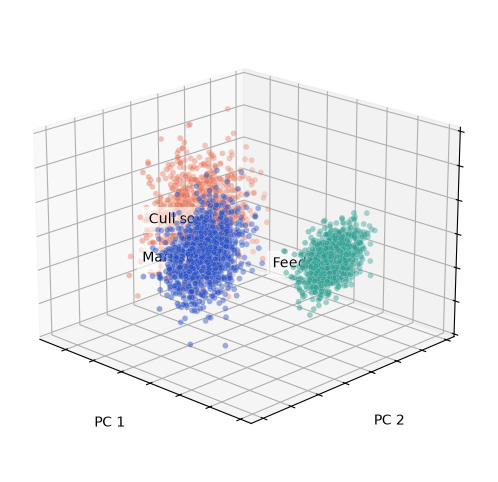

In [54]:
features = ['live_weight_kg', 'backfat_mm', 'loin_depth_mm', 'age_days']

#encode market class using dummy coding
classes = ['feeder_pig', 'market_hog', 'cull_sow']
y = data['market_class'].map({c: i for i, c in enumerate(classes)}).to_numpy()

#standardize variables then us Principal Component Analysis
X = PCA(n_components=3, random_state=0).fit_transform(StandardScaler().fit_transform(data[features]))


fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')   # not Axes3D(fig, rect=...)
ax.view_init(elev=20, azim=134)

colors = ['#2a9d8f', '#264cc4', '#e76f51']
labels = ['Feeder pig', 'Market hog', 'Cull sow']
for i, (name, clr) in enumerate(zip(labels, colors)):
    m = y == i
    ax.scatter(X[m, 0], X[m, 1], X[m, 2], c=clr, s=18, alpha=0.7,
               edgecolor='w', linewidth=0.2, label=name)
    ax.text(X[m, 0].mean(), X[m, 1].mean() + 0.4, X[m, 2].mean(), name,
            ha='center', bbox=dict(alpha=0.6, edgecolor='w', facecolor='w'))
    
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
plt.show()

**Initializing the Model**

In [55]:
#Fit Linear Regression Model on training data
#Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.7, random_state= 3701)

#Utilize Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=2, random_state=3701)
clf.fit(X_train, y_train)
preds = clf.predict_proba(X_test)
print("Accuracy: {:.5f}".format(accuracy_score(y_test, preds.argmax(axis = 1))))

Accuracy: 1.00000


**Implementing PCA**

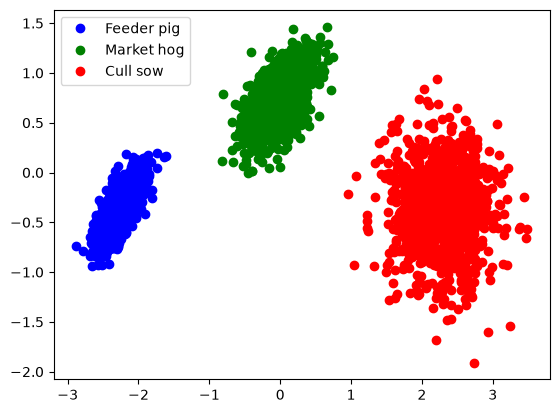

In [56]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_centered = X - X.mean(axis = 0)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)

#Visualize results
plt.plot(X_pca[y == 0, 0], X_pca[y == 0, 1], 'bo', label='Feeder pig')
plt.plot(X_pca[y == 1, 0], X_pca[y == 1, 1], 'go', label='Market hog')
plt.plot(X_pca[y == 2, 0], X_pca[y == 2, 1], 'ro', label='Cull sow')
plt.legend(loc=0);


In [57]:
# Test-train split and apply PCA
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=.3, stratify=y, random_state=42)

clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict_proba(X_test)
print('Accuracy: {:.5f}'.format(accuracy_score(y_test, preds.argmax(axis=1))))

Accuracy: 1.00000


Since our dataset is simple, using PCA to decrease dimensions did not improve accuracy for model

**Data Analysis**

In [58]:
data.columns

Index(['live_weight_kg', 'backfat_mm', 'loin_depth_mm', 'age_days',
       'market_class', 'value_usd'],
      dtype='str')

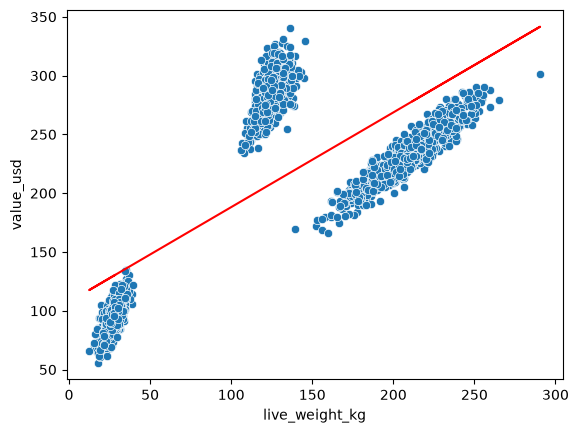

In [59]:
#live_weight-kg vs value_usd

sns.scatterplot(x = "live_weight_kg", y = "value_usd", data = data)
x = data['live_weight_kg']
y = data['value_usd']

slope, intercept = np.polyfit(x,y,1)
line = slope * x + intercept
plt.plot(x, line, color = 'red')

plt.show()

<Axes: xlabel='value_usd', ylabel='Count'>

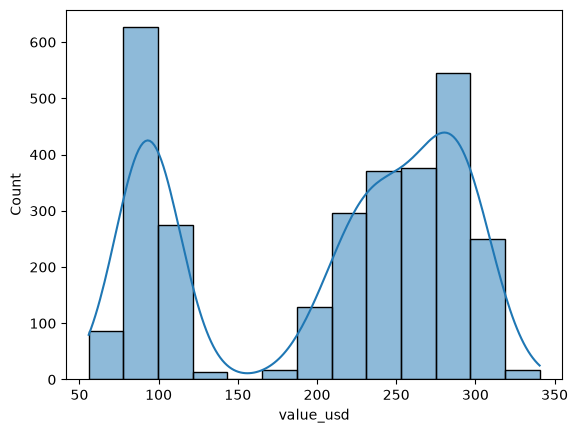

In [60]:
#value_usd Histogram - Distribution of value
sns.histplot(data["value_usd"], kde = "True")

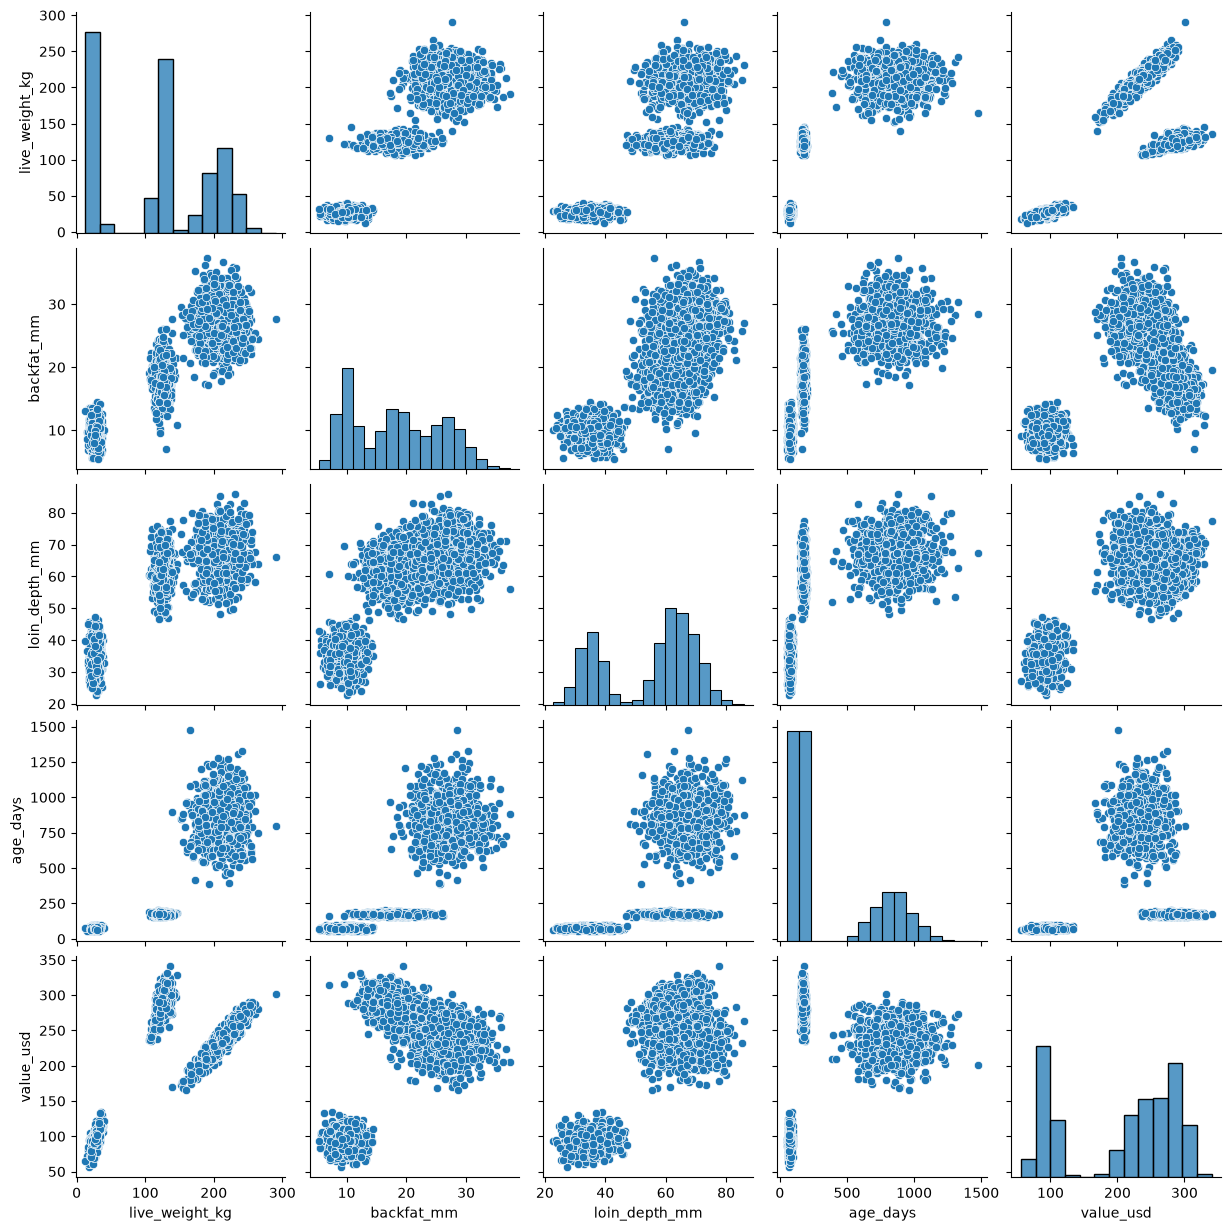

In [61]:
#Pairwise Plot
sns.pairplot(data)
plt.show()